In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import myplotlib
import myplotlib.plots as myplt
import compton
myplotlib.load()


In [114]:
gammas = None

energies_0 = None
energies_1 = None
energies_2 = None
energies_3 = None
    
with h5py.File("../prtl.tot.00100", "r") as f:
    energies_0 = np.sqrt(f["u_3"][:]**2 + f["v_3"][:]**2 + f["w_3"][:]**2)
    gammas = np.concatenate((np.sqrt(1.0 + f['u_1'][:]**2 + f['v_1'][:]**2 + f['w_1'][:]**2), np.sqrt(1.0 + f['u_2'][:]**2 + f['v_2'][:]**2 + f['w_2'][:]**2)))
        
with h5py.File("../build/ssc01.h5", "r") as f:
    energies_3 = f["e_ph"][:]

        
with h5py.File("../build/ssc1.h5", "r") as f:
    energies_1 = f["e_ph"][:]

with h5py.File("../build/ssc5.h5", "r") as f:
    energies_2 = f["e_ph"][:]

with h5py.File("../build/ssc5.h5", "r") as f:
    energies_2 = f["e_ph"][:]
    
with h5py.File("../spec.tot.00100", "r") as f:
    spec_photons = np.sum(f['n3'][:], axis=(1, 2, 3))
    spec_ebins = f['ebins'][:]


Text(0, 0.5, '$\\gamma-1 f(\\gamma)$')

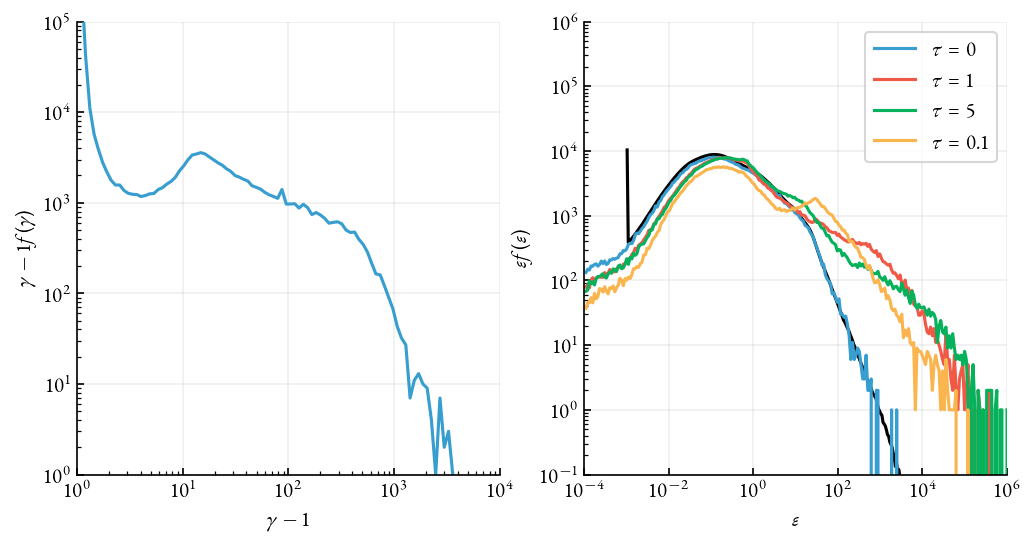

In [118]:
fig = plt.figure(figsize=(8, 4))
ax1 = plt.subplot(121)
ax2 = plt.subplot(122)

ebins = np.logspace(-4, 6, 250)

e0, _ = np.histogram(energies_0, bins=ebins)
e1, _ = np.histogram(energies_1, bins=ebins)
e2, _ = np.histogram(energies_2, bins=ebins)
e3, _ = np.histogram(energies_3, bins=ebins)

lims = dict(xlog=True, ylog=True, xlim=(1e-4, 1e6), ylim=(0.1, 1e6))
myplt.plot(ax2, spec_ebins, spec_photons / 3e4, c='k')
myplt.plot(ax2, ebins[1:], e0, **lims, c='C0', label=r"$\tau=0$")
myplt.plot(ax2, ebins[1:], e1, **lims, c='C1', label=r"$\tau=1$")
myplt.plot(ax2, ebins[1:], e2, **lims, c='C2', label=r"$\tau=5$")
myplt.plot(ax2, ebins[1:], e3, **lims, c='C3', label=r"$\tau=0.1$")
plt.legend()

ax2.set_xlabel(r"$\varepsilon$")
ax2.set_ylabel(r"$\varepsilon f(\varepsilon)$")


gbins = np.logspace(0, 4, 100)
g0, _ = np.histogram(gammas, bins=gbins)

lims = dict(xlog=True, ylog=True, xlim=(1, 1e4), ylim=(1, 1e5))
myplt.plot(ax1, gbins[1:], g0, **lims, c='C0')
plt.legend()

ax1.set_xlabel(r"$\gamma-1$")
ax1.set_ylabel(r"$\gamma-1 f(\gamma)$")


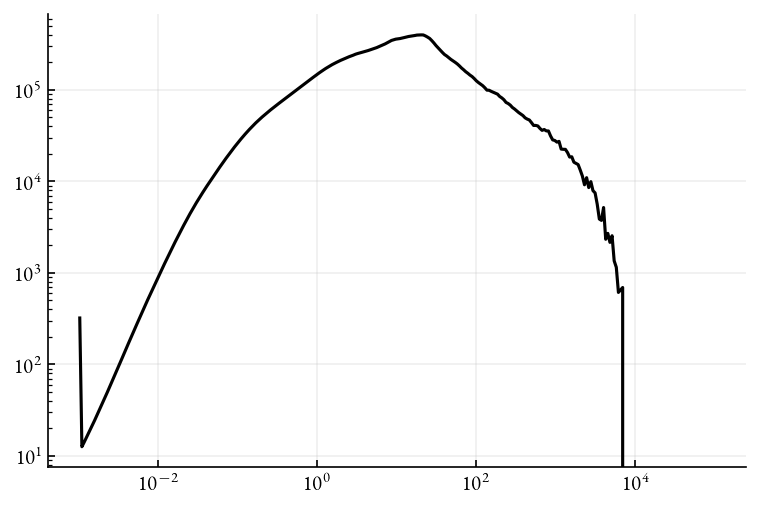

In [109]:
plt.plot(spec_ebins, spec_photons * spec_ebins / 1e3, c='k')
plt.xscale('log')
plt.yscale('log')
